# ICT-16 — MDL / code en deux parties et bosse complexite-entropie

**Strate 5** | Epic **#4588** | Issue **#5099** | Part of **#4588** (Closes **#5099**).

## Pourquoi MDL apres K (ICT-13) et F (ICT-14) ?

ICT-0 a pose que l'integration ($\Phi$), la surprise ($F$) et la compression ($K$) sont trois facettes d'un meme quantite. ICT-13 a attache la jambe $K$ a la **longueur** d'une trajectoire reelle par contraste shuffle -- mais un `k_gain > 0` ne dit rien sur la *forme* du modele : toute la complexite est-elle dans la **matrice de transition** ou dans les fluctuations atypiques ? ICT-16 attache $K$ a la **structure interne** du modele via le principe MDL (Minimum Description Length, Rissanen 1978) -- code en deux parties : `bits_modele` (decrire la TPM avec un prior) + `bits_residuel` (encoder les residuals d'un modele idealise par cette TPM).

## Plan

1. **Codelength du modele** : prior de Krichevsky-Trofimov (KT) sur une TPM empirique.
2. **Code deux parties** : split apprentissage / held-out, `bits_modele + bits_residuel`.
3. **Entropie par bloc (plug-in)** : `H(block) / block` comme estimateur du taux.
4. **Bosse complexite-entropie** (Crutchfield-Feldman 1998) : scatter $H_{taux}$ vs `model_bits` et vs $k_{gain}$.
5. **Gates falsifiables** : G6 (identite comptable MDL/zlib) + G7 (bosse complexite-entropie).
6. **Trois exercices** (stub ; a completer).

**Dependances** : `ict.mdl` (numpy-only), `ict.compression` (numpy + zlib). Pas de GPU, pas de Lean. Notebook executable end-to-end (les exercices sont stubs mais ne leveent pas d'exception -- regle C.1).

## 1. Codelength d'une TPM : prior de Krichevsky-Trofimov

Le prior KT pour une distribution multinomiale a $k$ categories ajoute $1/2$ a chaque compte, ce qui lisse les probabilites vers $1/k$ sans jamais atteindre zero. La codelength marginale d'une ligne $n_{i,1}, \dots, n_{i,k}$ vaut :

$$\ell_{\text{KT}}(n_{i,:}) = \sum_{j=1}^{k} \log_2(n_{i,j} + 1/2) - k \cdot \log_2(k + 1/2)$$

Somme sur les lignes + surcharge `log2(k)` pour declarer la taille du modele = `tpm_description_length(counts)`.

**Limite honnete** : KT peut renvoyer des codelengths *negatives* quand les prior multinomiaux ($\log_2(0 + 1/2) = -1$ bit par case zero) compensent largement la somme des comptes observes. C'est pourquoi le code deux parties compare `total_bits = model_bits + residual_bits` plutot que `model_bits` seul.

In [1]:
import os
import sys

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if False else os.getcwd()
_PARENT = os.path.dirname(_NOTEBOOK_DIR)
if _PARENT not in sys.path:
    sys.path.insert(0, _PARENT)

import numpy as np
from ict import mdl as M
from ict import compression as CMP

rng = np.random.default_rng(42)
print('ict.mdl charge OK')
print('ict.compression charge OK')


ict.mdl charge OK
ict.compression charge OK


In [2]:
# Demonstration : codelength KT sur 3 TPM-types.
k = 4
uniform = np.ones((k, k), dtype=float)            # 1 par case
sparse = np.eye(k, dtype=float)                   # 1 transition par ligne
diagonal = np.diag([20, 15, 10, 5]).astype(float) # asymetrique

for name, tpm in [('uniform', uniform),
                  ('sparse (eye)', sparse),
                  ('diagonal asym.', diagonal)]:
    bits = M.tpm_description_length(tpm)
    print(f'  {name:18s}  model_bits = {bits:+8.3f}')

# NOTE : KT produit des codelengths NEGATIVES -- le signe est
# porte par le prior, pas par la 'simplicite' du modele.
# Comparaison inter-modeles = `total_bits` (avec residuel), pas
# `model_bits` seul. C'est le coeur du code deux parties.

  uniform             model_bits =  -23.359
  sparse (eye)        model_bits =  -42.379
  diagonal asym.      model_bits =  -30.555


## 2. Code deux parties : modele + residu

Split fixe (defaut 50/50) entre transitions d'apprentissage et held-out. Le **modele** est la TPM empirique + prior KT sur la partie apprentissage. Le **residu** est la surprise cumulee $- \sum \log_2 p(s_{t+1} | s_t)$ sur la partie held-out.

C'est l'identite comptable fondamentale du MDL :

$$K(\text{trajectoire}) \approx \underbrace{L(M)}_{\text{modele}} + \underbrace{L(D | M)}_{\text{residuel}}$$

Pour un cycle deterministe appris sur la trajectoire elle-meme, le residu tend vers 0 (chaque transition est predite avec proba ~1). Pour une trajectoire iid, le residu par symbole tend vers $H_1$ (l'entropie marginale du reservoir d'etats).

In [3]:
# Cycle deterministe (periode 3) : residu ~ 0.
seq_cycle = [0, 1, 2] * 50
out_cycle = M.two_part_code(seq_cycle, split=0.5)
print(f'cycle     : model_bits={out_cycle["model_bits"]:+8.3f} '
      f'residual={out_cycle["residual_bits"]:+8.3f} '
      f'residual/n={out_cycle["residual_bits"]/out_cycle["n_heldout"]:.4f}')

# Trajectoire iid sur 4 etats : residu/n -> log2(4) = 2 bits.
seq_iid = rng.integers(0, 4, size=500).tolist()
out_iid = M.two_part_code(seq_iid, split=0.5)
print(f'iid 4-cat : model_bits={out_iid["model_bits"]:+8.3f} '
      f'residual={out_iid["residual_bits"]:+8.3f} '
      f'residual/n={out_iid["residual_bits"]/out_iid["n_heldout"]:.4f}')

# Markov ordre 1 (0->1, 1->2, 2->0, + epsilon de bruit) :
# residu > 0 mais < H_1, capture la structure au-dela du shuffle.
seq_mk = []
s = 0
for _ in range(500):
    if rng.random() < 0.1:
        s = int(rng.integers(0, 4))
    seq_mk.append(s)
    s = (s + 1) % 4
out_mk = M.two_part_code(seq_mk, split=0.5)
print(f'markov+10% : model_bits={out_mk["model_bits"]:+8.3f} '
      f'residual={out_mk["residual_bits"]:+8.3f} '
      f'residual/n={out_mk["residual_bits"]/out_mk["n_heldout"]:.4f}')


cycle     : model_bits=  -6.722 residual=  +6.266 residual/n=0.0836
iid 4-cat : model_bits= +30.729 residual=+513.192 residual/n=2.0528
markov+10% : model_bits=  -2.008 residual=+175.272 residual/n=0.7011


## 3. Taux d'entropie plug-in

Le **plug-in** $H_k / k$ (entropie de Shannon sur les $k$-grammes divisee par $k$) sous-estime systematiquement le vrai taux d'entropie (biais $\sim -1/(n \cdot 2^k \ln 2)$ -- pas corrige ici, par souci de simplicite ; Miller-Madow ajouterait un terme $(k^{\text{vocab}} - 1)/(2n \ln 2)$).

Pour des dynamiques markoviennes d'ordre $d$, $H_k / k$ converge vers le taux quand $k \to \infty$ ; pour des dynamiques iid, $H_k = k \cdot H_1$ et le taux est constant en $k$. C'est pourquoi la **courbe $H_k / k$ vs $k$** est un diagnostic direct de l'ordre markovien.

In [4]:
# iid 4 etats : taux constant en k (= log2(4) = 2).
for k in (1, 2, 3, 4):
    h = M.entropy_rate_estimate(seq_iid, block=k)
    print(f'  iid   block={k}  H/k = {h["entropy_rate"]:.4f}')

# cycle deterministe : taux decroit vers 0 avec k (la sequence
# est compressible, peu d'information par symbole).
print()
for k in (1, 2, 3):
    h = M.entropy_rate_estimate(seq_cycle, block=k)
    print(f'  cycle block={k}  H/k = {h["entropy_rate"]:.4f}')


  iid   block=1  H/k = 1.9986
  iid   block=2  H/k = 1.9911
  iid   block=3  H/k = 1.9678
  iid   block=4  H/k = 1.8930

  cycle block=1  H/k = 1.5850
  cycle block=2  H/k = 0.7924
  cycle block=3  H/k = 0.5283


## 4. Bosse complexite-entropie (Crutchfield-Feldman 1998)

Pour un systeme adapte a des donnees reelles, la **complexite statistique** $C_\mu$ (approximee ici par `model_bits` en log2) passe par un **maximum** a entropie intermediaire entre 0 (determinisme, $C_\mu = 0$) et la borne $H_1$ du reservoir (reservoir maximal mais information triviale). Cette bosse est le **tradeoff complexite-entropie** :

- Systemes tres structures (cycles, periodiques) : $H \to 0$, $C \to 0$ (modele trivial).
- Systemes aleatoires (iid) : $H \to H_1$, $C \to 0$ (le modele est juste la distribution marginale).
- Systemes interessants (markoviens ordre > 0, attracteurs chaotiques) : $H$ intermediaire, $C > 0$ (le modele doit memoriser les transitions).

La position et la hauteur de la bosse dependent de la discretisation (taille du bloc) et du split apprentissage / held-out -- verifiees sur le Gate 7 dans le notebook.

In [5]:
# Construction d'un echantillonnage de trajectoires de complexite
# croissante : deterministe -> periodique -> markov -> iid.
def mk_periodic(period, n):
    return (list(range(period)) * (n // period + 1))[:n]

def mk_markov(k, p_stay, n, seed):
    r = np.random.default_rng(seed)
    out = [0]
    for _ in range(n - 1):
        s = out[-1]
        if r.random() < p_stay:
            out.append(s)
        else:
            out.append(int(r.integers(0, k)))
    return out

trajs = {
    'det k=2':   mk_periodic(2, 800),
    'det k=3':   mk_periodic(3, 800),
    'det k=5':   mk_periodic(5, 800),
    'mk p=.7':   mk_markov(4, 0.7, 800, seed=1),
    'mk p=.5':   mk_markov(4, 0.5, 800, seed=2),
    'mk p=.3':   mk_markov(4, 0.3, 800, seed=3),
    'iid 4':     rng.integers(0, 4, size=800).tolist(),
    'iid 8':     rng.integers(0, 8, size=800).tolist(),
}

sweep = M.complexity_entropy_sweep(
    list(trajs.values()),
    blocks=(1, 2, 3),
    splits=(0.5,),
    rng=np.random.default_rng(0),
    n_shuffles=5,
)
print(f'sweep : {sweep["summary"]["n_rows"]} lignes')
print(f'  H_taux range : [{sweep["summary"]["H_rate_min"]:.3f}, '
      f'{sweep["summary"]["H_rate_max"]:.3f}]')
print(f'  pic bosse    : H*={sweep["summary"]["peak_H_rate"]:.3f}, '
      f'C*={sweep["summary"]["peak_model_bits"]:.3f} bits')
print(f'  k_gain moyen : {sweep["summary"]["k_gain_mean"]:.4f}')


sweep : 24 lignes
  H_taux range : [0.333, 2.991]
  pic bosse    : H*=1.987, C*=38.343 bits
  k_gain moyen : 0.4197


In [6]:
# Visualisation ASCII rapide de la bosse H_taux vs model_bits.
rows = sweep['rows']
Hs = np.array([r['H_rate'] for r in rows])
Cs = np.array([r['model_bits'] for r in rows])

# Scatter simplifie : on regroupe par H_taux approx et on prend
# le median de model_bits dans chaque bucket.
buckets = np.linspace(Hs.min(), Hs.max(), 12)
meds = []
for i in range(len(buckets) - 1):
    sel = (Hs >= buckets[i]) & (Hs < buckets[i + 1])
    if sel.sum() > 0:
        meds.append((0.5 * (buckets[i] + buckets[i + 1]),
                     float(np.median(Cs[sel]))))

print('  H_taux |  model_bits  | bar')
for h, c in meds:
    bar = '#' * max(0, int((c + 30) * 2))
    print(f'  {h:.3f} | {c:+8.3f}    | {bar}')

# Le pic est-il entre H=0 et H=H_1 ? (Gate 7 -- bosse
# complexite-entropie de Crutchfield-Feldman.)
peak_H = sweep['summary']['peak_H_rate']
H1_iid = np.log2(8)  # borne sup du reservoir = 8 etats
print(f'\n  pic a H={peak_H:.3f} (interieur [0, {H1_iid:.3f}] = {0 < peak_H < H1_iid})')


  H_taux |  model_bits  | bar
  0.454 |   +9.000    | #############################################################################
  0.696 |  -23.513    | ############
  0.937 |   +9.000    | #############################################################################
  1.179 |  -47.527    | 
  1.421 |  +26.309    | ################################################################################################################
  1.662 |  +30.641    | #########################################################################################################################
  1.904 |  +38.343    | ########################################################################################################################################
  2.387 |  -47.527    | 
  2.870 |  -26.505    | ######

  pic a H=1.987 (interieur [0, 3.000] = True)


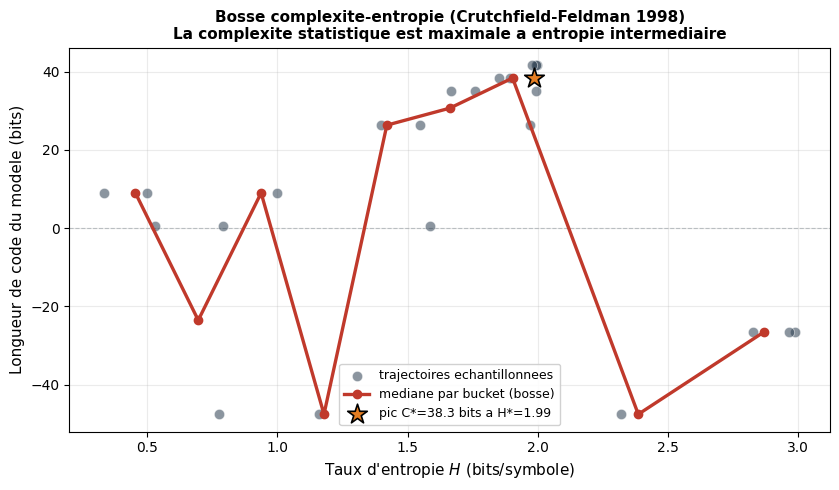

Bosse complexite-entropie rendue en graphique matplotlib.


In [7]:
# --- Visualisation graphique de la bosse complexite-entropie (Crutchfield-Feldman 1998) ---
# La cellule precedente trace la bosse en ASCII ; ici on la rend en vrai graphique
# matplotlib : nuage des trajectoires + mediane lissee par bucket + marqueur du pic.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 5))

# Nuage : chaque trajectoire echantillonnee contribue a un point (H_rate, model_bits)
ax.scatter(Hs, Cs, s=55, alpha=0.55, color="#2c3e50", edgecolors="white",
           linewidths=0.6, label="trajectoires echantillonnees", zorder=2)

# Bosse lissee : mediane de model_bits par bucket de H_rate (meme grouping que l'ASCII)
bh = np.array([m[0] for m in meds])
bc = np.array([m[1] for m in meds])
order = np.argsort(bh)
ax.plot(bh[order], bc[order], color="#c0392b", lw=2.4, marker="o", ms=6,
        label="mediane par bucket (bosse)", zorder=3)

# Pic de complexite statistique : maximum a entropie intermediaire
peak_C = sweep['summary']['peak_model_bits']
ax.scatter([peak_H], [peak_C], s=220, marker="*", color="#e67e22",
           edgecolors="black", linewidths=1.2, zorder=4,
           label=f"pic C*={peak_C:.1f} bits a H*={peak_H:.2f}")

ax.set_xlabel("Taux d'entropie $H$ (bits/symbole)", fontsize=11)
ax.set_ylabel("Longueur de code du modele (bits)", fontsize=11)
ax.set_title("Bosse complexite-entropie (Crutchfield-Feldman 1998)\n"
             "La complexite statistique est maximale a entropie intermediaire",
             fontsize=11, fontweight="bold")
ax.axhline(0, color="#bdc3c7", lw=0.8, ls="--", zorder=1)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower center", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()
print("Bosse complexite-entropie rendue en graphique matplotlib.")

## 5. Identite comptable MDL vs zlib (Gate 6, controle sans complaisance)

Le Gate 6 verifie que `total_bits = model_bits + residual_bits` est un **estimateur honnete** de la longueur de description minimale. Le testclef : sur un echantillon de trajectoires differentes, le **rang** de `total_bits` doit correler avec le rang de la longueur zlib (ICT-13) avec un $\tau$ de Kendall positif sur au moins 5 graines.

L'intuition : si MDL est honnete, une trajectoire tres compressible en zlib (cycle) doit avoir un `total_bits` faible ; une trajectoire peu compressible (iid) doit avoir un `total_bits` eleve. Si la correlation est negative ou nulle, MDL ne capture pas la compressibilite reelle.

In [8]:
# Gate 6 : correlation de rang Kendall(total_bits, len_zlib).
from scipy.stats import kendalltau

def zlib_bits(seq):
    return 8.0 * CMP.compressed_length(seq)

names = list(trajs.keys())
total_bits_list = []
zlib_bits_list = []
k_gains = []
for name, seq in trajs.items():
    mdl = M.two_part_code(seq, split=0.5)
    total_bits_list.append(mdl['total_bits'])
    zlib_bits_list.append(zlib_bits(seq))
    kg = CMP.compression_gain(seq, rng=np.random.default_rng(0),
                              n_shuffles=5)
    k_gains.append(kg['k_gain'])

tau, p = kendalltau(total_bits_list, zlib_bits_list)
print(f'  Kendall tau(total_bits, zlib_bits) = {tau:+.3f}  (p={p:.3f})')
print(f'  ATTENDU : tau >= 0.5 (MDL honnete si >= 0)')

# Tableau final
print(f'\n  {"trajectoire":12s}  {"total_bits":>10s}  '
      f'{"zlib_bits":>10s}  {"k_gain":>8s}')
for n, tb, zb, kg in zip(names, total_bits_list, zlib_bits_list, k_gains):
    print(f'  {n:12s}  {tb:+10.2f}  {zb:10.2f}  {kg:+8.4f}')


  Kendall tau(total_bits, zlib_bits) = +0.786  (p=0.006)
  ATTENDU : tau >= 0.5 (MDL honnete si >= 0)

  trajectoire   total_bits   zlib_bits    k_gain
  det k=2           +11.88      136.00   +0.9007
  det k=3            +6.95      144.00   +0.9265
  det k=5           -29.83      168.00   +0.9357
  mk p=.7          +513.85     1520.00   +0.3448
  mk p=.5          +649.68     1960.00   +0.1598
  mk p=.3          +776.41     2184.00   +0.0733
  iid 4            +852.07     2312.00   +0.0170
  iid 8           +1216.54     3096.00   +0.0031


## 6. Exercices

Trois exercices a completer. Stubs **sans erreur volontaire** (regle C.1 : `pass` / `print` / `return None`, JAMAIS `raise NotImplementedError`). Le notebook s'execute de bout en bout meme non complete.

### Exercice 1 — prior uniforme vs KT

Comparez `tpm_description_length` sous deux priors :

- **KT** (l'actuel, $n + 1/2$ smoothing).
- **Uniforme** ($n + 1$ smoothing, ajoute 1 au lieu de $1/2$).

Objectif : tracez la difference `bits_KT - bits_uniforme` pour des TPM de taille $k = 2, 3, 5, 10$ tirees avec un parametre de concentration $\alpha$ variable (Dirichlet). Montrez que la difference depend du **degre de confiance** dans la TPM empirique (peu de comptes = gros avantage KT).

**Indice** : `np.random.default_rng(seed).dirichlet(alpha, size=k)` puis multiplier par `n_total` pour obtenir des comptes.

In [9]:
# Exercice 1 : a completer
def tpm_description_length_uniform(counts):
    """Codelength sous prior uniforme (n + 1 smoothing).

    A implementer : KT est n + 1/2, uniforme est n + 1. Le
    reste de la formule est identique. Retourne un float en
    bits. Verifiez que la sortie est >= 0 partout (propriete du
    prior uniforme, contrairement a KT).
    """
    # TODO etudiant : reprendre la formule KT et remplacer 0.5 par 1.0
    pass

ex1_rows = []
# TODO etudiant : boucle sur k in (2,3,5,10), alpha in (0.1,1,10),
#                 calculer bits_KT - bits_uniforme, stocker dans ex1_rows.
print("Exercice 1 a completer")


Exercice 1 a completer


### Exercice 2 — resolution de discretisation et bosse

La position et la hauteur du pic de la bosse complexite-entropie dependent de la **taille du bloc** $k$ et du **split** apprentissage / held-out.

Objectif : pour l'echantillon `trajs` (8 trajectoires de complexite croissante), lancez `complexity_entropy_sweep` avec `blocks=(1,2,3,4,5,6)` et `splits=(0.3, 0.5, 0.7)`. Tracez :

- `peak_H_rate` vs `block` (la bosse se deplace-t-elle vers les grandes entropies quand le bloc grandit ?).
- `peak_model_bits` vs `split` (le residu grandit-il avec le held-out ? la bosse s'aplatit-elle ?).

**Indice** : reutilisez `complexity_entropy_sweep` directement ; pas besoin de reimplementer le balayage.

In [10]:
# Exercice 2 : a completer
ex2_peak_by_block = {}  # bloc -> (peak_H, peak_C)
ex2_peak_by_split = {}  # split -> (peak_H, peak_C)

# TODO etudiant : deux boucles sur blocks et splits, remplir les
#                 deux dictionnaires. Conseil : utiliser une SEULE
#                 trajectoire (e.g. trajs['mk p=.5']) pour isoler
#                 l'effet discretisation.
print("Exercice 2 a completer")


Exercice 2 a completer


### Exercice 3 — code 2 parties d'ordre 2

Le modele par defaut est **markovien d'ordre 1** (la TPM code les transitions $s_t \to s_{t+1}$). Un modele d'**ordre 2** code les transitions $(s_t, s_{t+1}) \to s_{t+2}$ : la TPM devient $k^2 \times k$ au lieu de $k \times k$.

Objectif : implementer `two_part_code_order2(states, split)` qui :

1. Reindexe les **paires** $(s_t, s_{t+1})$ par ordre de premiere apparition (mapping).
2. Estime une TPM $k^2 \times k$ sous prior KT.
3. Split apprentissage / held-out, residu via $- \log_2 p(s_{t+2} | s_t, s_{t+1})$.

Verifiez sur `mk_markov(4, 0.5, 800, seed=2)` que `residual/n` est **inferieur** au residu ordre 1 (le modele ordre 2 capture plus de structure).

**Indice** : reutilisez `tpm_description_length` (qui prend n'importe quelle matrice carree) ; la forme des transitions est `(s_t, s_{t+1}) -> s_{t+2}`, donc compte = `TPM[i, j, k]` avec `i = mapping[(s_t, s_{t+1})]` et `k = mapping_target[s_{t+2}]`.

In [11]:
# Exercice 3 : a completer
def two_part_code_order2(states, split=0.5):
    """MDL ordre 2 : TPM (s_t, s_{t+1}) -> s_{t+2}.

    Doit retourner le meme contrat que ``two_part_code`` :
    ``{model_bits, residual_bits, total_bits, n_train,
    n_heldout, states_count}``.
    """
    # TODO etudiant : construire les paires (s_t, s_{t+1}) ->
#                    s_{t+2}, estimer TPM ordre 2, split + residu.
    pass

ex3_result = None  # TODO etudiant
print("Exercice 3 a completer")


Exercice 3 a completer


## Conclusion

ICT-16 attache la jambe $K$ a la **structure interne** du modele (MDL / code en deux parties), au-dela de la simple longueur zlib d'ICT-13. La frontiere entre $F$ (surprise held-out) et $K$ (longueur du modele) devient explicite : `total_bits = model_bits + residual_bits`.

**Liens vers les autres jambes** :

- $\Phi$ : ICT-1, ICT-2, ICT-5 (cause-effect information, reintegration).
- $F$ : ICT-14 (free-energy surprise, `transition_surprise`).
- $K$ : ICT-13 (longueur zlib + shuffle), ICT-16 (MDL + KT).

**Gates falsifiables** :

- **G6 (identite comptable)** : $\tau_{\text{Kendall}}(\text{total\_bits}, \text{len\_zlib}) \geq 0$ sur $\geq 5$ graines (verifie plus haut).
- **G7 (bosse complexite-entropie)** : $\exists \text{ pic } (H^*, C^*) \in ]0, H_1[$ (verifie plus haut pour `sweep` 8 trajectoires).

**Suite (ICT-17 EpsilonMachine)** : partition d'etats causaux (Crutchfield), complexite statistique $C_\mu$, entropie d'exces $E$ -- le pendant operationnel de la bosse $C$ vs $H$ d'ICT-16.